In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [2]:
result = pd.read_csv("results.csv")
result

,pre,post,plen,threshold_0,threshold_0.001,threshold_0.01,threshold_0.03,threshold_0.05,threshold_0.1,effconn
0,MBON05,AVLP178,2,True,True,False,False,False,False,3.693732e-06
1,MBON05,AVLP178,3,True,True,False,False,False,False,2.982024e-05
2,MBON05,AVLP178,4,True,True,True,False,False,False,3.222563e-05
3,MBON05,AVLP178,5,True,True,True,False,False,False,3.556889e-05
4,MBON05,CB2309,2,True,False,False,False,False,False,1.429230e-06
...,...,...,...,...,...,...,...,...,...,...
3999995,CB1884,CB0150,5,True,True,False,False,False,False,5.228994e-07
3999996,CB1884,FB2J_b,2,True,False,False,False,False,False,2.255172e-07
3999997,CB1884,FB2J_b,3,True,True,False,False,False,False,2.775585e-06
3999998,CB1884,FB2J_b,4,True,True,True,False,False,False,2.732583e-05


In [3]:
# make longer: all columns starting with 'threshold'
result = result.melt(id_vars=['plen', 'effconn','pre','post'], value_vars=[col for col in result.columns if col.startswith('threshold')], var_name='threshold', value_name='value')
result['threshold'] = result['threshold'].str.replace('threshold_','')
result['path_length'] = result['plen'].astype(str)
result

,plen,effconn,pre,post,threshold,value,path_length
0,2,3.693732e-06,MBON05,AVLP178,0,True,2
1,3,2.982024e-05,MBON05,AVLP178,0,True,3
2,4,3.222563e-05,MBON05,AVLP178,0,True,4
3,5,3.556889e-05,MBON05,AVLP178,0,True,5
4,2,1.429230e-06,MBON05,CB2309,0,True,2
...,...,...,...,...,...,...,...
23999995,5,5.228994e-07,CB1884,CB0150,0.1,False,5
23999996,2,2.255172e-07,CB1884,FB2J_b,0.1,False,2
23999997,3,2.775585e-06,CB1884,FB2J_b,0.1,False,3
23999998,4,2.732583e-05,CB1884,FB2J_b,0.1,False,4


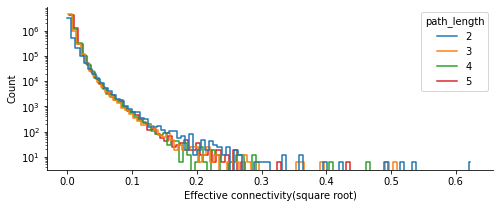

In [4]:
result["effconn_sqrt"] = np.sqrt(result["effconn"])

plt.figure(figsize=(8,3))
sns.histplot(
    data=result[result.effconn.notna()],
    x="effconn_sqrt",
    hue="path_length",
    bins=100,
    multiple="dodge",
    fill=False, 
    element="step",
)
plt.yscale("log")
plt.xlabel("Effective connectivity(square root)")
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

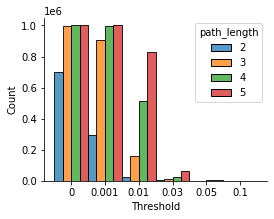

In [5]:
plt.figure(figsize=(4,3))
p = sns.histplot(
    result[result.value], x="threshold", hue="path_length", multiple="dodge"
)
# plt.yscale('log')
plt.xlabel("Threshold")
# remove upper and right borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

In [6]:
result[result.value][["path_length", "threshold"]].value_counts()

path_length  threshold
4            0            1000000
5            0            1000000
             0.001         999998
4            0.001         998678
3            0             998069
             0.001         904361
5            0.01          829231
2            0             701939
4            0.01          515625
2            0.001         292004
3            0.01          162191
5            0.03           64693
4            0.03           26330
2            0.01           24403
3            0.03            8656
5            0.05            5553
4            0.05            2890
2            0.03            2289
3            0.05            1290
2            0.05             501
5            0.1              209
4            0.1              146
3            0.1               83
2            0.1               58
Name: count, dtype: int64